In [ ]:
# Install all required libraries — every notebook is self-contained
!pip install fastapi uvicorn scikit-fem nest-asyncio requests pyngrok meshio -q

import nest_asyncio
nest_asyncio.apply()

print("✅ Libraries installed and nest-asyncio applied")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 10.2 MB/s eta 0:00:00
✅ Libraries installed and nest-asyncio applied


In [ ]:
import os
import json
import time
import logging
import threading
import requests
import asyncio
import uvicorn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List
from uvicorn import Config, Server
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/MCL_Orchestrator/'

PATHS = {
    'notebooks' : f'{DRIVE_PATH}notebooks/',
    'services'  : f'{DRIVE_PATH}services/',
    'results'   : f'{DRIVE_PATH}results/',
    'logs'      : f'{DRIVE_PATH}logs/',
    'docs'      : f'{DRIVE_PATH}docs/'
}

# Confirm folders
print("\nConfirming Drive folder structure:")
print("=" * 45)
all_exist = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ Missing"
    print(f"  {name:<12} : {status}")
    if not exists:
        all_exist = False

print("=" * 45)
if all_exist:
    print("✅ All folders confirmed")
else:
    print("❌ Some folders missing — check Drive before continuing")

Mounted at /content/drive

Confirming Drive folder structure:
  notebooks    : ✅ Found
  services     : ✅ Found
  results      : ✅ Found
  logs         : ✅ Found
  docs         : ✅ Found
✅ All folders confirmed


In [ ]:
# ── Logger ────────────────────────────────────────────────────────
log_file_path = f'{DRIVE_PATH}logs/pipeline.log'

if not os.path.exists(log_file_path):
    with open(log_file_path, 'w') as f:
        f.write(f"MCL Orchestrator — Pipeline Log\n")
        f.write(f"Created : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 60 + "\n")

logger = logging.getLogger('MCL_Orchestrator')
logger.setLevel(logging.INFO)

if not logger.handlers:
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)
    file_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

def log_event(stage, status, detail=''):
    message = f"{stage:<30} | {status:<10} | {detail}"
    if status == 'ERROR':
        logger.error(message)
    elif status == 'WARNING':
        logger.warning(message)
    else:
        logger.info(message)

# ── Pipeline State ────────────────────────────────────────────────
state_file_path = f'{DRIVE_PATH}logs/pipeline_state.json'

pipeline_state = {
    'job_id'      : None,
    'started_at'  : None,
    'stages'      : {
        'A_parameter_generation': 'pending',
        'B_fem_simulation'      : 'pending',
        'C_postprocessing'      : 'pending'
    },
    'errors'      : [],
    'completed_at': None
}

def update_state(stage, status, error=None):
    pipeline_state['stages'][stage] = status
    if error:
        pipeline_state['errors'].append({
            'stage'    : stage,
            'error'    : str(error),
            'timestamp': datetime.now().isoformat()
        })
        log_event(stage, 'ERROR', str(error))
    else:
        log_event(stage, status, f"Stage updated to {status}")
    with open(state_file_path, 'w') as f:
        json.dump(pipeline_state, f, indent=4)

# ── Retry Handler ─────────────────────────────────────────────────
def post_with_retry(url, data, max_retries=3, backoff=2):
    log_event('retry_handler', 'INFO',
              f"POST to {url} | max_retries={max_retries}")
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=data, timeout=30)
            response.raise_for_status()
            log_event('retry_handler', 'SUCCESS',
                      f"POST succeeded on attempt {attempt + 1}")
            return response.json()
        except requests.exceptions.ConnectionError:
            if attempt < max_retries - 1:
                wait = backoff ** attempt
                print(f"  ⚠️  Service unreachable — retrying in {wait}s "
                      f"(attempt {attempt + 1}/{max_retries})")
                log_event('retry_handler', 'WARNING',
                          f"Connection failed — retrying in {wait}s")
                time.sleep(wait)
            else:
                log_event('retry_handler', 'ERROR',
                          f"Unreachable after {max_retries} attempts")
                raise RuntimeError(
                    f"❌ Service at {url} unreachable after {max_retries} attempts"
                )
        except requests.exceptions.Timeout:
            log_event('retry_handler', 'ERROR', f"Timeout at {url}")
            raise RuntimeError(f"❌ Service at {url} timed out")
        except requests.exceptions.HTTPError as e:
            log_event('retry_handler', 'ERROR', f"HTTP error: {e}")
            raise RuntimeError(f"❌ HTTP error: {e}")

print("✅ Shared utilities reinitialised:")
print("   Logger        : ✅ handler guard active")
print("   State tracker : ✅ ready")
print("   Retry handler : ✅ ready")
log_event('03_service_C', 'INFO',
          'Shared utilities initialised in Notebook 4')

✅ Shared utilities reinitialised:
   Logger        : ✅ handler guard active
   State tracker : ✅ ready
   Retry handler : ✅ ready


2026-06-02 05:43:51 | INFO | 03_service_C                   | INFO       | Shared utilities initialised in Notebook 4
INFO:MCL_Orchestrator:03_service_C                   | INFO       | Shared utilities initialised in Notebook 4


In [ ]:
class FEMResult(BaseModel):
    job_id                      : str
    max_axial_displacement_mm   : float
    max_lateral_displacement_mm : float
    axial_strain                : float
    effective_modulus_GPa       : float
    applied_stress_MPa          : float
    fiber_volume_fraction       : float
    E_input_GPa                 : float
    E_fiber_GPa                 : float
    E_matrix_GPa                : float
    nu_input                    : float
    length_mm                   : float
    width_mm                    : float
    n_nodes                     : int
    n_elements                  : int
    status                      : str
    modulus_error_pct           : Optional[float] = None
    issues                      : Optional[List[str]] = []
    warnings                    : Optional[List[str]] = []
    lame_lambda                 : Optional[float] = None
    lame_mu                     : Optional[float] = None

# Print schema
print("FEM Result Input Schema — FEMResult")
print("=" * 60)
print(f"  {'Field':<35} {'Type':<10} {'Source'}")
print("  " + "-" * 55)

fields_info = {
    'job_id'                      : ('str',           'Service A — traceability'),
    'max_axial_displacement_mm'   : ('float',         'Service B — FEM output'),
    'max_lateral_displacement_mm' : ('float',         'Service B — FEM output'),
    'axial_strain'                : ('float',         'Service B — FEM output'),
    'effective_modulus_GPa'       : ('float',         'Service B — FEM output'),
    'applied_stress_MPa'          : ('float',         'Service B — FEM output'),
    'fiber_volume_fraction'       : ('float',         'Service A — traceability'),
    'E_input_GPa'                 : ('float',         'Service A — traceability'),
    'E_fiber_GPa'                 : ('float',         'Service A — traceability'),
    'E_matrix_GPa'                : ('float',         'Service A — traceability'),
    'nu_input'                    : ('float',         'Service A — traceability'),
    'length_mm'                   : ('float',         'Service A — geometry'),
    'width_mm'                    : ('float',         'Service A — geometry'),
    'n_nodes'                     : ('int',           'Service B — mesh info'),
    'n_elements'                  : ('int',           'Service B — mesh info'),
    'status'                      : ('str',           'Service B — complete/warned/failed'),
    'modulus_error_pct'           : ('float|None',    'Service B — optional'),
    'issues'                      : ('List[str]|None','Service B — optional'),
    'warnings'                    : ('List[str]|None','Service B — optional'),
    'lame_lambda'                 : ('float|None',    'Service B — optional'),
    'lame_mu'                     : ('float|None',    'Service B — optional')
}

for field, (ftype, source) in fields_info.items():
    print(f"  {field:<35} {ftype:<15} {source}")

print("=" * 60)

# Sample payload as it would arrive from Service B
sample = FEMResult(
    job_id                      = 'SAMPLE01',
    max_axial_displacement_mm   = 0.130566,
    max_lateral_displacement_mm = 0.006134,
    axial_strain                = 0.00130566,
    effective_modulus_GPa       = 229.77,
    applied_stress_MPa          = 300.0,
    fiber_volume_fraction       = 0.45,
    E_input_GPa                 = 220.5,
    E_fiber_GPa                 = 380.0,
    E_matrix_GPa                = 90.0,
    nu_input                    = 0.20,
    length_mm                   = 100.0,
    width_mm                    = 20.0,
    n_nodes                     = 126,
    n_elements                  = 200,
    status                      = 'complete',
    modulus_error_pct           = 4.2
)

print(f"\n  Sample payload from Service B:")
print(f"  " + "-" * 45)
for field, value in sample.model_dump().items():
    if value is not None and value != []:
        print(f"    {field:<35} : {value}")
print(f"  " + "-" * 45)
print(f"\n✅ FEMResult schema defined")

FEM Result Input Schema — FEMResult
  Field                               Type       Source
  -------------------------------------------------------
  job_id                              str             Service A — traceability
  max_axial_displacement_mm           float           Service B — FEM output
  max_lateral_displacement_mm         float           Service B — FEM output
  axial_strain                        float           Service B — FEM output
  effective_modulus_GPa               float           Service B — FEM output
  applied_stress_MPa                  float           Service B — FEM output
  fiber_volume_fraction               float           Service A — traceability
  E_input_GPa                         float           Service A — traceability
  E_fiber_GPa                         float           Service A — traceability
  E_matrix_GPa                        float           Service A — traceability
  nu_input                            float           Service A — trac

In [ ]:
def check_stress_strain_consistency(result: FEMResult):
    """
    Verifies sigma = E x epsilon holds within tolerance.
    Uses FEM-computed values to check internal consistency.
    """
    # Recompute stress from FEM modulus and strain
    sigma_computed = result.effective_modulus_GPa * 1e3 * result.axial_strain
    sigma_applied  = result.applied_stress_MPa
    error_pct      = abs(sigma_computed - sigma_applied) / sigma_applied * 100

    passed = error_pct < 10  # 10% tolerance

    return {
        'check'          : 'Stress-Strain Consistency',
        'sigma_applied'  : round(sigma_applied,  2),
        'sigma_computed' : round(sigma_computed, 2),
        'error_pct'      : round(error_pct,      2),
        'tolerance_pct'  : 10,
        'passed'         : passed,
        'note'           : 'sigma = E x epsilon verified'
    }

def check_poisson_effect(result: FEMResult):
    """
    Verifies lateral strain / axial strain is close to nu.
    Confirms Poisson contraction is physically correct.
    """
    lateral_strain  = result.max_lateral_displacement_mm / result.width_mm
    axial_strain    = result.axial_strain
    nu_computed     = lateral_strain / (axial_strain + 1e-12)
    nu_input        = result.nu_input
    error_pct       = abs(nu_computed - nu_input) / nu_input * 100

    passed = error_pct < 20  # 20% tolerance — Poisson more sensitive to mesh

    return {
        'check'        : 'Poisson Effect',
        'nu_input'     : round(nu_input,     3),
        'nu_computed'  : round(nu_computed,  3),
        'error_pct'    : round(error_pct,    2),
        'tolerance_pct': 20,
        'passed'       : passed,
        'note'         : 'lateral/axial strain ratio verified'
    }

def check_modulus_consistency(result: FEMResult):
    """
    Compares FEM-computed effective modulus against
    the Voigt prediction passed from Service A.
    """
    E_voigt    = result.E_input_GPa
    E_fem      = result.effective_modulus_GPa
    error_pct  = abs(E_fem - E_voigt) / E_voigt * 100

    passed = error_pct < 15  # 15% tolerance

    return {
        'check'        : 'Modulus Consistency',
        'E_voigt_GPa'  : round(E_voigt,   3),
        'E_fem_GPa'    : round(E_fem,     3),
        'error_pct'    : round(error_pct, 2),
        'tolerance_pct': 15,
        'passed'       : passed,
        'note'         : 'FEM modulus vs Voigt prediction'
    }

def run_all_checks(result: FEMResult):
    """
    Runs all three analysis checks and returns
    a combined summary with overall pass/fail status.
    """
    checks = [
        check_stress_strain_consistency(result),
        check_poisson_effect(result),
        check_modulus_consistency(result)
    ]
    all_passed = all(c['passed'] for c in checks)
    return {
        'checks'     : checks,
        'all_passed' : all_passed,
        'timestamp'  : datetime.now().isoformat()
    }

# ── Test all checks with known SiC/SiC results ───────────────────
print("Analysis Checks — SiC/SiC Standard Case")
print("=" * 58)

analysis = run_all_checks(sample)

for check in analysis['checks']:
    icon = "✅" if check['passed'] else "❌"
    print(f"\n  {icon} {check['check']}")
    print(f"     Error     : {check['error_pct']}%")
    print(f"     Tolerance : {check['tolerance_pct']}%")
    print(f"     Note      : {check['note']}")

print(f"\n  {'=' * 45}")
print(f"  Overall result : "
      f"{'✅ All checks passed' if analysis['all_passed'] else '❌ Some checks failed'}")
print(f"  {'=' * 45}")
print(f"\n✅ Analysis functions confirmed")

Analysis Checks — SiC/SiC Standard Case

  ✅ Stress-Strain Consistency
     Error     : 0.0%
     Tolerance : 10%
     Note      : sigma = E x epsilon verified

  ✅ Poisson Effect
     Error     : 17.45%
     Tolerance : 20%
     Note      : lateral/axial strain ratio verified

  ✅ Modulus Consistency
     Error     : 4.2%
     Tolerance : 15%
     Note      : FEM modulus vs Voigt prediction

  Overall result : ✅ All checks passed

✅ Analysis functions confirmed


Testing results plot with sample SiC/SiC data:
---------------------------------------------


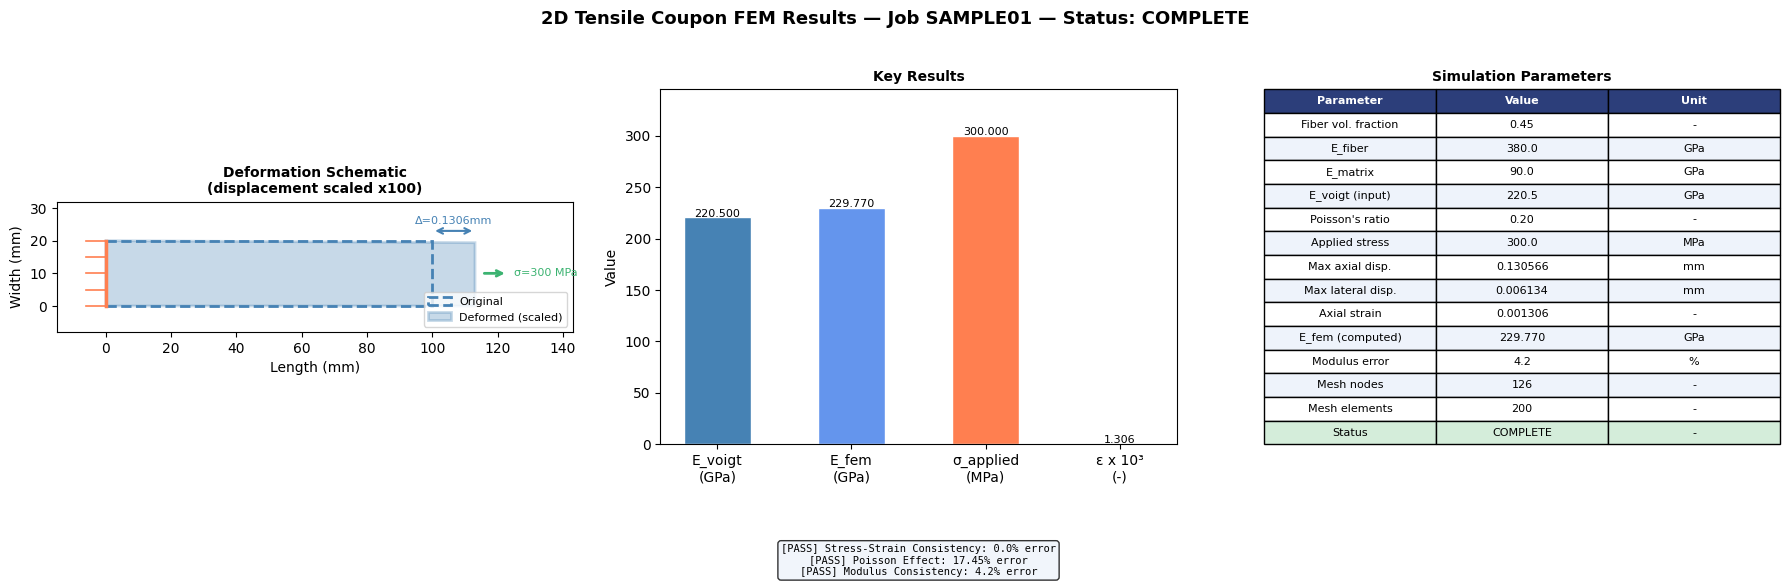

2026-06-02 06:25:41 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=SAMPLE01 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_SAMPLE01.png
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=SAMPLE01 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_SAMPLE01.png



✅ Plot confirmed saved to Drive:
   /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_SAMPLE01.png
   File exists: True


In [ ]:
def generate_results_plot(result: FEMResult, analysis: dict, job_id: str):
    """
    Generates a three-panel results figure:
    Panel 1 — Deformation schematic
    Panel 2 — Key metrics bar chart
    Panel 3 — Summary parameter table
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'2D Tensile Coupon FEM Results — Job {job_id} — '
        f'Status: {result.status.upper()}',
        fontsize=13, fontweight='bold', y=1.02
    )

    # ── Panel 1 — Deformation schematic ──────────────────────────
    ax1 = axes[0]

    L          = result.length_mm
    W          = result.width_mm
    disp_scale = result.max_axial_displacement_mm * 100

    # Original coupon outline
    original = plt.Polygon(
        [[0, 0], [L, 0], [L, W], [0, W]],
        fill      = False,
        edgecolor = 'steelblue',
        linewidth = 2,
        linestyle = '--',
        label     = 'Original'
    )

    # Deformed coupon outline
    lateral = result.max_lateral_displacement_mm * 100
    deformed = plt.Polygon(
        [[0, 0],
         [L + disp_scale, 0],
         [L + disp_scale, W - lateral],
         [0, W]],
        fill      = True,
        facecolor = 'steelblue',
        alpha     = 0.3,
        edgecolor = 'steelblue',
        linewidth = 2,
        label     = 'Deformed (scaled)'
    )

    ax1.add_patch(original)
    ax1.add_patch(deformed)

    # Fixed support symbols on left
    for y in np.linspace(0, W, 5):
        ax1.plot([-6, 0], [y, y], color='coral', linewidth=1.2)
    ax1.plot([0, 0], [0, W], color='coral', linewidth=2.5)

    # Load arrow on right
    ax1.annotate(
        '',
        xy     = (L + disp_scale + 10, W / 2),
        xytext = (L + disp_scale + 2, W / 2),
        arrowprops=dict(arrowstyle='->', color='mediumseagreen', lw=2)
    )
    ax1.text(L + disp_scale + 12, W / 2,
             f"σ={result.applied_stress_MPa:.0f} MPa",
             color='mediumseagreen', fontsize=8, va='center')

    # Displacement annotation
    ax1.annotate(
        '',
        xy     = (L + disp_scale, W + 3),
        xytext = (L, W + 3),
        arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5)
    )
    ax1.text(L + disp_scale / 2, W + 5,
             f"Δ={result.max_axial_displacement_mm:.4f}mm",
             color='steelblue', fontsize=8, ha='center')

    ax1.set_xlim(-15, L + disp_scale + 30)
    ax1.set_ylim(-8, W + 12)
    ax1.set_xlabel('Length (mm)', fontsize=10)
    ax1.set_ylabel('Width (mm)', fontsize=10)
    ax1.set_title('Deformation Schematic\n(displacement scaled x100)',
                  fontsize=10, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.set_aspect('equal')

    # ── Panel 2 — Key metrics bar chart ──────────────────────────
    ax2 = axes[1]

    metrics = {
        'E_voigt\n(GPa)'    : result.E_input_GPa,
        'E_fem\n(GPa)'      : result.effective_modulus_GPa,
        'σ_applied\n(MPa)'  : result.applied_stress_MPa,
        'ε x 10³\n(-)'      : result.axial_strain * 1000
    }

    colors = ['steelblue', 'cornflowerblue', 'coral', 'mediumseagreen']
    bars   = ax2.bar(
        metrics.keys(),
        metrics.values(),
        color     = colors,
        edgecolor = 'white',
        width     = 0.5
    )

    for bar, val in zip(bars, metrics.values()):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.3f}',
            ha='center', fontsize=8
        )

    # Analysis check results as text below chart
    check_lines = []
    for check in analysis['checks']:
      icon = "PASS" if check['passed'] else "FAIL"
      check_lines.append(
          f"[{icon}] {check['check']}: {check['error_pct']}% error"
      )

    ax2.text(
        0.5, -0.28,
        '\n'.join(check_lines),
        transform   = ax2.transAxes,
        fontsize    = 7.5,
        ha          = 'center',
        va          = 'top',
        family      = 'monospace',
        bbox        = dict(boxstyle='round', facecolor='#eef3fb',
                          alpha=0.8)
    )

    ax2.set_title('Key Results', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Value')
    ax2.set_ylim(0, max(metrics.values()) * 1.15)

    # ── Panel 3 — Summary parameter table ────────────────────────
    ax3 = axes[2]
    ax3.axis('off')

    table_data = [
        ['Parameter',               'Value',       'Unit'],
        ['Fiber vol. fraction',     f"{result.fiber_volume_fraction:.2f}", '-'],
        ['E_fiber',                 f"{result.E_fiber_GPa:.1f}",  'GPa'],
        ['E_matrix',                f"{result.E_matrix_GPa:.1f}", 'GPa'],
        ['E_voigt (input)',         f"{result.E_input_GPa:.1f}",  'GPa'],
        ["Poisson's ratio",         f"{result.nu_input:.2f}",     '-'],
        ['Applied stress',          f"{result.applied_stress_MPa:.1f}", 'MPa'],
        ['Max axial disp.',         f"{result.max_axial_displacement_mm:.6f}", 'mm'],
        ['Max lateral disp.',       f"{result.max_lateral_displacement_mm:.6f}", 'mm'],
        ['Axial strain',            f"{result.axial_strain:.6f}", '-'],
        ['E_fem (computed)',        f"{result.effective_modulus_GPa:.3f}", 'GPa'],
        ['Modulus error',           f"{result.modulus_error_pct:.1f}" if result.modulus_error_pct else 'N/A', '%'],
        ['Mesh nodes',              f"{result.n_nodes}",     '-'],
        ['Mesh elements',           f"{result.n_elements}",  '-'],
        ['Status',                  result.status.upper(),   '-']
    ]

    table = ax3.table(
        cellText  = [row for row in table_data[1:]],
        colLabels = table_data[0],
        cellLoc   = 'center',
        loc       = 'center',
        bbox      = [0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)

    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e7a')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#eef3fb')
        else:
            cell.set_facecolor('white')
        # Highlight status row
        if r == len(table_data) - 1:
            color = '#d4edda' if result.status == 'complete' else \
                    '#fff3cd' if result.status == 'warned' else '#f8d7da'
            cell.set_facecolor(color)

    ax3.set_title('Simulation Parameters', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Save to Drive
    plot_path = f'{DRIVE_PATH}results/fem_results_{job_id}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    log_event('Service C — plot', 'SUCCESS',
              f"Plot saved | job={job_id} | {plot_path}")

    return plot_path

# ── Test with sample SiC/SiC result ──────────────────────────────
print("Testing results plot with sample SiC/SiC data:")
print("-" * 45)

test_analysis = run_all_checks(sample)
plot_path     = generate_results_plot(sample, test_analysis, 'SAMPLE01')

print(f"\n✅ Plot confirmed saved to Drive:")
print(f"   {plot_path}")
print(f"   File exists: {os.path.exists(plot_path)}")

In [ ]:
def save_metrics_json(result: FEMResult, analysis: dict, plot_path: str):
    """
    Assembles and saves a structured JSON containing all
    inputs, outputs, analysis check results, timestamps,
    and file paths for full traceability.
    """

    metrics = {
        'job_id'    : result.job_id,
        'timestamp' : datetime.now().isoformat(),
        'status'    : result.status,

        'inputs': {
            'E_fiber_GPa'          : result.E_fiber_GPa,
            'E_matrix_GPa'         : result.E_matrix_GPa,
            'E_voigt_GPa'          : result.E_input_GPa,
            'fiber_volume_fraction': result.fiber_volume_fraction,
            'nu'                   : result.nu_input,
            'applied_stress_MPa'   : result.applied_stress_MPa,
            'length_mm'            : result.length_mm,
            'width_mm'             : result.width_mm
        },

        'fem_outputs': {
            'max_axial_displacement_mm'  : result.max_axial_displacement_mm,
            'max_lateral_displacement_mm': result.max_lateral_displacement_mm,
            'axial_strain'               : result.axial_strain,
            'effective_modulus_GPa'      : result.effective_modulus_GPa,
            'modulus_error_pct'          : result.modulus_error_pct,
            'n_nodes'                    : result.n_nodes,
            'n_elements'                 : result.n_elements
        },

        'analysis_checks': {
            check['check']: {
                'passed'       : check['passed'],
                'error_pct'    : check['error_pct'],
                'tolerance_pct': check['tolerance_pct']
            }
            for check in analysis['checks']
        },

        'overall_passed' : analysis['all_passed'],

        'issues'   : result.issues   if result.issues   else [],
        'warnings' : result.warnings if result.warnings else [],

        'files': {
            'plot'  : plot_path,
            'log'   : log_file_path,
            'state' : state_file_path
        }
    }

    # Save to Drive
    json_path = f'{DRIVE_PATH}results/metrics_{result.job_id}.json'
    with open(json_path, 'w') as f:
        json.dump(metrics, f, indent=4)

    log_event('Service C — metrics', 'SUCCESS',
              f"Metrics JSON saved | job={result.job_id}")

    return json_path, metrics

# ── Test with sample SiC/SiC result ──────────────────────────────
print("Testing metrics JSON with sample SiC/SiC data:")
print("-" * 45)

json_path, metrics = save_metrics_json(
    result    = sample,
    analysis  = test_analysis,
    plot_path = plot_path
)

# Read back from Drive and confirm
with open(json_path, 'r') as f:
    loaded = json.load(f)

print(f"✅ Metrics JSON saved and read back from Drive:")
print(f"   Path        : {json_path}")
print(f"   File exists : {os.path.exists(json_path)}")
print(f"\n   Top-level keys:")
for key in loaded.keys():
    print(f"     - {key}")

print(f"\n   Analysis checks stored:")
for check_name, check_data in loaded['analysis_checks'].items():
    icon = "✅" if check_data['passed'] else "❌"
    print(f"     {icon} {check_name:<35} : "
          f"{check_data['error_pct']}% error")

print(f"\n   Overall passed : "
      f"{'✅ Yes' if loaded['overall_passed'] else '❌ No'}")
print(f"\n✅ Metrics JSON function confirmed")

2026-06-02 06:26:02 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=SAMPLE01
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=SAMPLE01


Testing metrics JSON with sample SiC/SiC data:
---------------------------------------------
✅ Metrics JSON saved and read back from Drive:
   Path        : /content/drive/MyDrive/MCL_Orchestrator/results/metrics_SAMPLE01.json
   File exists : True

   Top-level keys:
     - job_id
     - timestamp
     - status
     - inputs
     - fem_outputs
     - analysis_checks
     - overall_passed
     - issues
     - warnings
     - files

   Analysis checks stored:
     ✅ Stress-Strain Consistency           : 0.0% error
     ✅ Poisson Effect                      : 17.45% error
     ✅ Modulus Consistency                 : 4.2% error

   Overall passed : ✅ Yes

✅ Metrics JSON function confirmed


In [ ]:
app_c = FastAPI(
    title       = "Service C — Postprocessor",
    description = "Receives FEM results from Service B, runs "
                  "analysis checks, generates results plot, "
                  "saves metrics JSON, and updates pipeline state.",
    version     = "1.0.0"
)

# ── POST /postprocess ─────────────────────────────────────────────
@app_c.post('/postprocess')
def postprocess(result: FEMResult):

    update_state('C_postprocessing', 'running')
    log_event('Service C', 'INFO',
              f"Postprocessing started | job={result.job_id} | "
              f"status={result.status}")

    try:
        # Handle failed results — log and save minimal JSON, no plot
        if result.status == 'failed':
            log_event('Service C', 'WARNING',
                      f"Received failed result | job={result.job_id} | "
                      f"issues={result.issues}")

            failure_record = {
                'job_id'   : result.job_id,
                'timestamp': datetime.now().isoformat(),
                'status'   : 'failed',
                'issues'   : result.issues,
                'inputs'   : {
                    'E_input_GPa'          : result.E_input_GPa,
                    'fiber_volume_fraction': result.fiber_volume_fraction,
                    'applied_stress_MPa'   : result.applied_stress_MPa
                }
            }

            failure_path = f'{DRIVE_PATH}results/failed_{result.job_id}.json'
            with open(failure_path, 'w') as f:
                json.dump(failure_record, f, indent=4)

            update_state('C_postprocessing', 'failed',
                         f"Received failed FEM result: {result.issues}")

            log_event('Service C', 'ERROR',
                      f"Failure record saved | job={result.job_id}")

            return {
                'status'      : 'failed',
                'job_id'      : result.job_id,
                'issues'      : result.issues,
                'saved_to'    : failure_path
            }

        # Run analysis checks
        analysis = run_all_checks(result)

        log_event('Service C', 'INFO',
                  f"Analysis checks complete | "
                  f"all_passed={analysis['all_passed']} | "
                  f"job={result.job_id}")

        # Generate results plot
        plot_path = generate_results_plot(
            result   = result,
            analysis = analysis,
            job_id   = result.job_id
        )

        # Save metrics JSON
        json_path, metrics = save_metrics_json(
            result    = result,
            analysis  = analysis,
            plot_path = plot_path
        )

        # Update pipeline state
        pipeline_state['completed_at'] = datetime.now().isoformat()

        if result.status == 'warned':
            update_state('C_postprocessing', 'warned')
            log_event('Service C', 'WARNING',
                      f"Pipeline complete with warnings | "
                      f"job={result.job_id}")
        else:
            update_state('C_postprocessing', 'complete')
            log_event('Service C', 'SUCCESS',
                      f"Pipeline complete | job={result.job_id}")

        # Save final pipeline state to Drive
        final_state_path = (
            f'{DRIVE_PATH}logs/pipeline_state_{result.job_id}.json'
        )
        with open(final_state_path, 'w') as f:
            json.dump(pipeline_state, f, indent=4)

        return {
            'status'          : result.status,
            'job_id'          : result.job_id,
            'analysis_passed' : analysis['all_passed'],
            'plot_path'       : plot_path,
            'metrics_path'    : json_path,
            'state_path'      : final_state_path
        }

    except Exception as e:
        update_state('C_postprocessing', 'error', str(e))
        log_event('Service C', 'ERROR',
                  f"Unexpected error | job={result.job_id} | {str(e)}")
        raise HTTPException(
            status_code = 500,
            detail      = f"Postprocessing failed: {str(e)}"
        )

# ── GET /health ───────────────────────────────────────────────────
@app_c.get('/health')
def health_c():
    return {
        'service'  : 'C — Postprocessor',
        'status'   : 'online',
        'port'     : 8003,
        'timestamp': datetime.now().isoformat()
    }

# ── GET /state ────────────────────────────────────────────────────
@app_c.get('/state')
def state_c():
    return {
        'pipeline_state': pipeline_state,
        'timestamp'     : datetime.now().isoformat()
    }

# ── GET /results ──────────────────────────────────────────────────
@app_c.get('/results')
def list_results():
    results_path = f'{DRIVE_PATH}results/'
    try:
        files = os.listdir(results_path)
        plots  = [f for f in files if f.endswith('.png')]
        jsons  = [f for f in files if f.endswith('.json')]
        return {
            'results_folder' : results_path,
            'total_files'    : len(files),
            'plots'          : sorted(plots),
            'json_files'     : sorted(jsons)
        }
    except Exception as e:
        raise HTTPException(
            status_code = 500,
            detail      = f"Could not read results folder: {str(e)}"
        )

print("✅ Service C — FastAPI app defined")
print("\n  Endpoints registered:")
print("    POST /postprocess → analyse, plot, save, update state")
print("    GET  /health      → confirm service is online")
print("    GET  /state       → return current pipeline state")
print("    GET  /results     → list all saved result files")
print("\n  Ready to start on port 8003")

✅ Service C — FastAPI app defined

  Endpoints registered:
    POST /postprocess → analyse, plot, save, update state
    GET  /health      → confirm service is online
    GET  /state       → return current pipeline state
    GET  /results     → list all saved result files

  Ready to start on port 8003


In [ ]:
async def serve_c():
    config = Config(
        app       = app_c,
        host      = '0.0.0.0',
        port      = 8003,
        log_level = 'warning'
    )
    server = Server(config)
    await server.serve()

def run_service_c():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(serve_c())

# Start in background daemon thread
thread_c = threading.Thread(target=run_service_c, daemon=True)
thread_c.start()

# Wait for service to fully initialise
time.sleep(3)

# Health check
try:
    r = requests.get('http://localhost:8003/health', timeout=5)
    health = r.json()
    print("✅ Service C is online:")
    print(f"   Service  : {health['service']}")
    print(f"   Status   : {health['status']}")
    print(f"   Port     : {health['port']}")
    print(f"   Time     : {health['timestamp']}")
    log_event('Service C', 'INFO', 'Service C started on port 8003')
except Exception as e:
    print(f"❌ Service C health check failed: {e}")

2026-06-02 06:27:40 | INFO | Service C                      | INFO       | Service C started on port 8003
INFO:MCL_Orchestrator:Service C                      | INFO       | Service C started on port 8003


✅ Service C is online:
   Service  : C — Postprocessor
   Status   : online
   Port     : 8003
   Time     : 2026-06-02T06:27:40.660181


2026-06-02 06:29:15 | INFO | C_postprocessing               | running    | Stage updated to running
INFO:MCL_Orchestrator:C_postprocessing               | running    | Stage updated to running


Test 1 — Direct Postprocessing Call


2026-06-02 06:29:16 | INFO | Service C                      | INFO       | Postprocessing started | job=DIRECT001 | status=complete
INFO:MCL_Orchestrator:Service C                      | INFO       | Postprocessing started | job=DIRECT001 | status=complete
2026-06-02 06:29:16 | INFO | Service C                      | INFO       | Analysis checks complete | all_passed=True | job=DIRECT001
INFO:MCL_Orchestrator:Service C                      | INFO       | Analysis checks complete | all_passed=True | job=DIRECT001


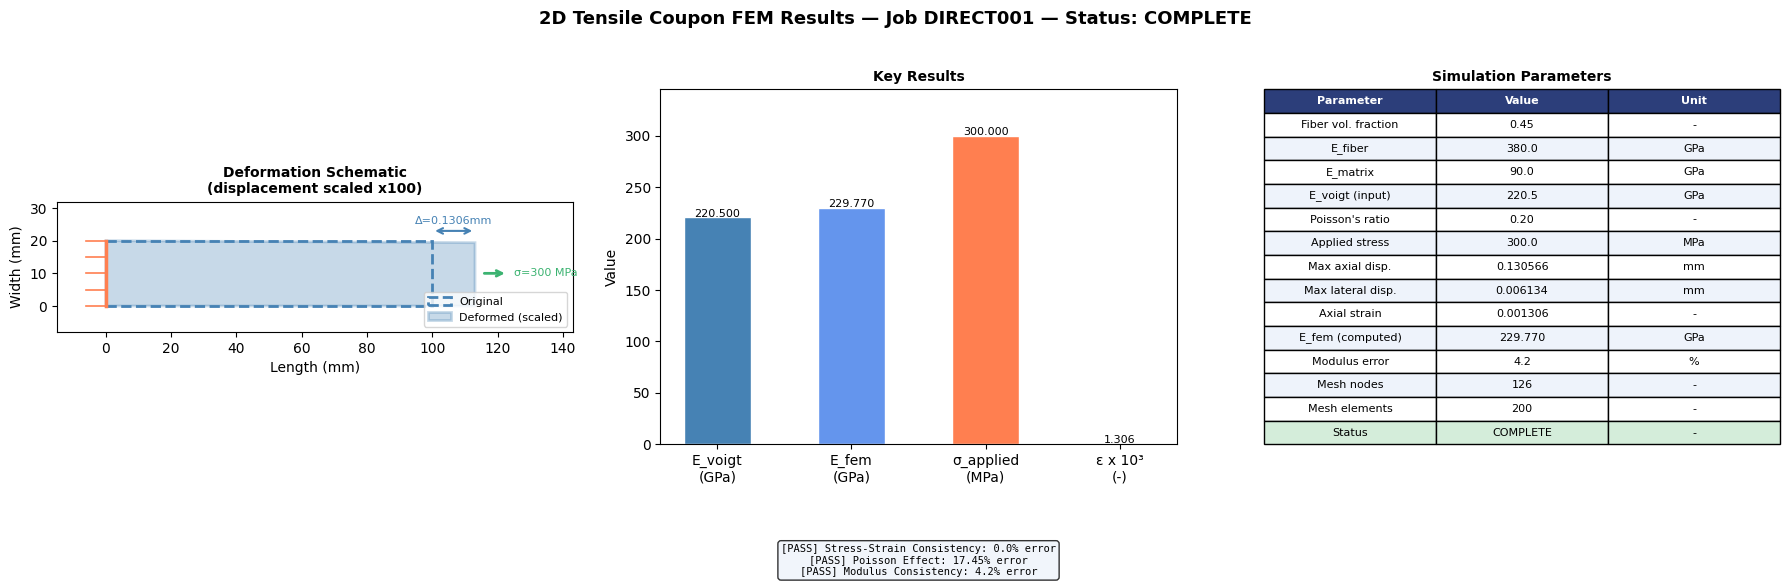

2026-06-02 06:29:17 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=DIRECT001 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_DIRECT001.png
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=DIRECT001 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_DIRECT001.png
2026-06-02 06:29:17 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=DIRECT001
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=DIRECT001
2026-06-02 06:29:17 | INFO | C_postprocessing               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:C_postprocessing               | complete   | Stage updated to complete
2026-06-02 06:29:17 | INFO | Service C                      | SUCCESS    | Pipeline complete | job=DIRECT001
INFO:MCL_Orchestrator:Service C                      | SUCCESS    | Pipeline complete | job=DIRECT001


  HTTP Status      : 200
  Pipeline status  : complete
  Job ID           : DIRECT001
  Analysis passed  : True

  Files saved to Drive:
    Plot   : /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_DIRECT001.png
    JSON   : /content/drive/MyDrive/MCL_Orchestrator/results/metrics_DIRECT001.json
    State  : /content/drive/MyDrive/MCL_Orchestrator/logs/pipeline_state_DIRECT001.json

  File existence check:
    Plot     : ✅ Found — /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_DIRECT001.png
    JSON     : ✅ Found — /content/drive/MyDrive/MCL_Orchestrator/results/metrics_DIRECT001.json
    State    : ✅ Found — /content/drive/MyDrive/MCL_Orchestrator/logs/pipeline_state_DIRECT001.json

  Pipeline stage status:
    ⏳ A_parameter_generation              : pending
    ⏳ B_fem_simulation                    : pending
    ✅ C_postprocessing                    : complete

✅ Test 1 complete — postprocessing working correctly


In [ ]:
# Send valid FEM result directly to Service C
valid_payload = {
    'job_id'                      : 'DIRECT001',
    'max_axial_displacement_mm'   : 0.130566,
    'max_lateral_displacement_mm' : 0.006134,
    'axial_strain'                : 0.00130566,
    'effective_modulus_GPa'       : 229.77,
    'applied_stress_MPa'          : 300.0,
    'fiber_volume_fraction'       : 0.45,
    'E_input_GPa'                 : 220.5,
    'E_fiber_GPa'                 : 380.0,
    'E_matrix_GPa'                : 90.0,
    'nu_input'                    : 0.20,
    'length_mm'                   : 100.0,
    'width_mm'                    : 20.0,
    'n_nodes'                     : 126,
    'n_elements'                  : 200,
    'status'                      : 'complete',
    'modulus_error_pct'           : 4.2
}

print("Test 1 — Direct Postprocessing Call")
print("=" * 50)

response = requests.post(
    'http://localhost:8003/postprocess',
    json    = valid_payload,
    timeout = 60
)

result = response.json()

print(f"  HTTP Status      : {response.status_code}")
print(f"  Pipeline status  : {result.get('status')}")
print(f"  Job ID           : {result.get('job_id')}")
print(f"  Analysis passed  : {result.get('analysis_passed')}")
print(f"\n  Files saved to Drive:")
print(f"    Plot   : {result.get('plot_path')}")
print(f"    JSON   : {result.get('metrics_path')}")
print(f"    State  : {result.get('state_path')}")

# Confirm files exist on Drive
print(f"\n  File existence check:")
for label, key in [('Plot', 'plot_path'),
                   ('JSON', 'metrics_path'),
                   ('State', 'state_path')]:
    path   = result.get(key, '')
    exists = os.path.exists(path)
    print(f"    {label:<8} : {'✅ Found' if exists else '❌ Missing'} — {path}")

# Check pipeline state
state = requests.get('http://localhost:8003/state', timeout=5).json()
stages = state['pipeline_state']['stages']
print(f"\n  Pipeline stage status:")
for stage, status in stages.items():
    icon = "✅" if status == 'complete' else \
           "⚠️ " if status == 'warned' else \
           "❌" if status in ['error', 'failed'] else "⏳"
    print(f"    {icon} {stage:<35} : {status}")

print(f"\n✅ Test 1 complete — postprocessing working correctly")

2026-06-02 06:29:42 | INFO | C_postprocessing               | running    | Stage updated to running
INFO:MCL_Orchestrator:C_postprocessing               | running    | Stage updated to running
2026-06-02 06:29:42 | INFO | Service C                      | INFO       | Postprocessing started | job=WARNED001 | status=warned
INFO:MCL_Orchestrator:Service C                      | INFO       | Postprocessing started | job=WARNED001 | status=warned
2026-06-02 06:29:42 | INFO | Service C                      | INFO       | Analysis checks complete | all_passed=False | job=WARNED001
INFO:MCL_Orchestrator:Service C                      | INFO       | Analysis checks complete | all_passed=False | job=WARNED001


Test 2 — Flagged Result Handling


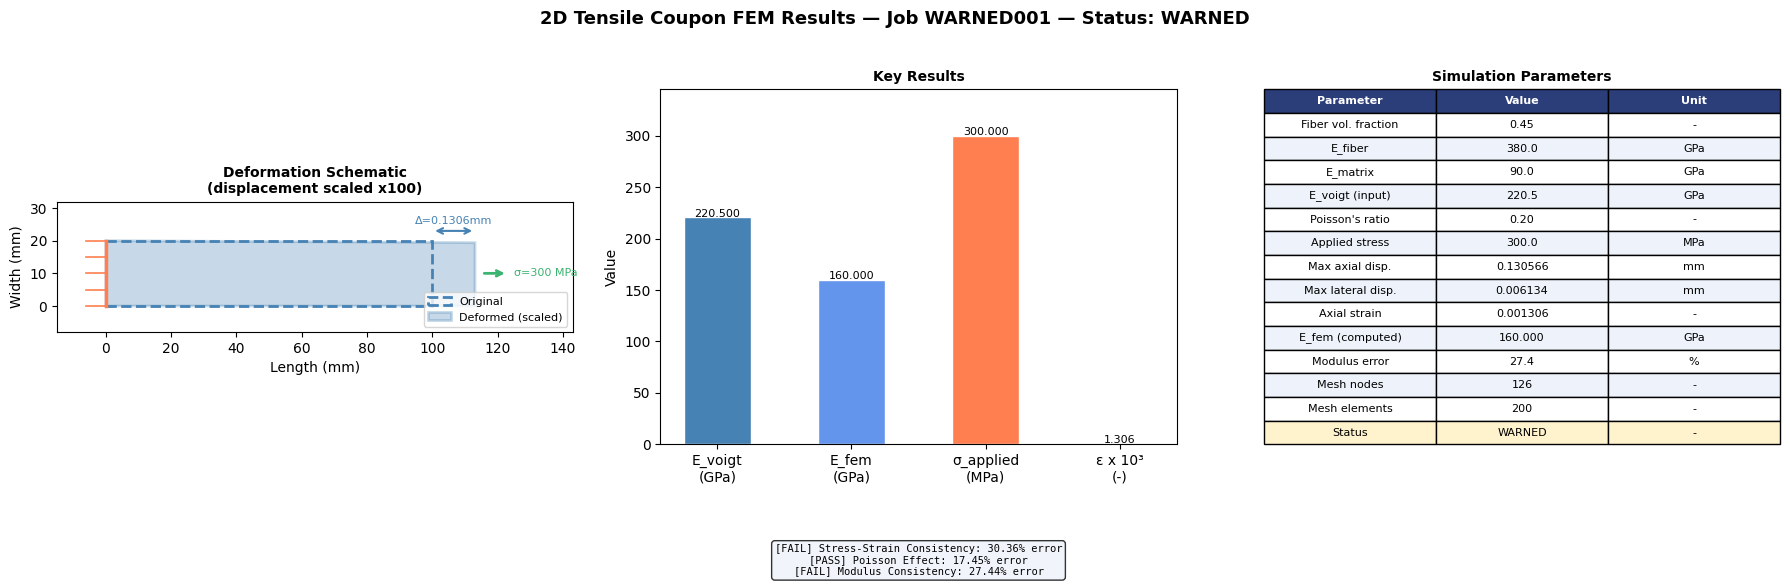

2026-06-02 06:29:44 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=WARNED001 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_WARNED001.png
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=WARNED001 | /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_WARNED001.png
2026-06-02 06:29:44 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=WARNED001
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=WARNED001
2026-06-02 06:29:44 | INFO | C_postprocessing               | warned     | Stage updated to warned
INFO:MCL_Orchestrator:C_postprocessing               | warned     | Stage updated to warned
2026-06-02 06:29:44 | WARNING | Service C                      | WARNING    | Pipeline complete with warnings | job=WARNED001


  HTTP Status      : 200
  Pipeline status  : warned
  Job ID           : WARNED001
  Analysis passed  : False

  Saved JSON status  : warned
  Warnings recorded  : ['Computed modulus (160.0 GPa) deviates 27.4% from input (220.5 GPa) — exceeds 15% tolerance']
  Analysis checks:
    ❌ Stress-Strain Consistency           : 30.36% error
    ✅ Poisson Effect                      : 17.45% error
    ❌ Modulus Consistency                 : 27.44% error

  Plot saved  : ✅
  Plot path   : /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_WARNED001.png

✅ Test 2 complete — warned result handled correctly


In [ ]:
# Send a warned result — modulus inconsistency flagged
warned_payload = {
    'job_id'                      : 'WARNED001',
    'max_axial_displacement_mm'   : 0.130566,
    'max_lateral_displacement_mm' : 0.006134,
    'axial_strain'                : 0.00130566,
    'effective_modulus_GPa'       : 160.0,    # causes modulus warning
    'applied_stress_MPa'          : 300.0,
    'fiber_volume_fraction'       : 0.45,
    'E_input_GPa'                 : 220.5,
    'E_fiber_GPa'                 : 380.0,
    'E_matrix_GPa'                : 90.0,
    'nu_input'                    : 0.20,
    'length_mm'                   : 100.0,
    'width_mm'                    : 20.0,
    'n_nodes'                     : 126,
    'n_elements'                  : 200,
    'status'                      : 'warned',
    'modulus_error_pct'           : 27.4,
    'warnings'                    : [
        'Computed modulus (160.0 GPa) deviates 27.4% '
        'from input (220.5 GPa) — exceeds 15% tolerance'
    ]
}

print("Test 2 — Flagged Result Handling")
print("=" * 50)

response = requests.post(
    'http://localhost:8003/postprocess',
    json    = warned_payload,
    timeout = 60
)

result = response.json()

print(f"  HTTP Status      : {response.status_code}")
print(f"  Pipeline status  : {result.get('status')}")
print(f"  Job ID           : {result.get('job_id')}")
print(f"  Analysis passed  : {result.get('analysis_passed')}")

# Confirm warned status in saved JSON
json_path = result.get('metrics_path', '')
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        saved = json.load(f)
    print(f"\n  Saved JSON status  : {saved['status']}")
    print(f"  Warnings recorded  : {saved['warnings']}")
    print(f"  Analysis checks:")
    for check_name, check_data in saved['analysis_checks'].items():
        icon = "✅" if check_data['passed'] else "❌"
        print(f"    {icon} {check_name:<35} : "
              f"{check_data['error_pct']}% error")
else:
    print(f"  ❌ JSON file not found at {json_path}")

# Confirm plot saved with warned status in title
plot_path = result.get('plot_path', '')
print(f"\n  Plot saved  : {'✅' if os.path.exists(plot_path) else '❌'}")
print(f"  Plot path   : {plot_path}")

print(f"\n✅ Test 2 complete — warned result handled correctly")

In [ ]:
# Send a failed result — physical plausibility checks failed
failed_payload = {
    'job_id'                      : 'FAILED001',
    'max_axial_displacement_mm'   : 150.0,    # exceeds length
    'max_lateral_displacement_mm' : 5.0,
    'axial_strain'                : 0.25,     # exceeds 10%
    'effective_modulus_GPa'       : -50.0,    # negative
    'applied_stress_MPa'          : 300.0,
    'fiber_volume_fraction'       : 0.45,
    'E_input_GPa'                 : 220.5,
    'E_fiber_GPa'                 : 380.0,
    'E_matrix_GPa'                : 90.0,
    'nu_input'                    : 0.20,
    'length_mm'                   : 100.0,
    'width_mm'                    : 20.0,
    'n_nodes'                     : 126,
    'n_elements'                  : 200,
    'status'                      : 'failed',
    'issues'                      : [
        'Axial displacement (150.0mm) exceeds coupon length (100.0mm)',
        'Non-physical negative modulus: -50.0 GPa',
        'Axial strain (0.2500) exceeds 10% — outside linear elastic range'
    ]
}

print("Test 3 — Failed Result Handling")
print("=" * 50)

response = requests.post(
    'http://localhost:8003/postprocess',
    json    = failed_payload,
    timeout = 30
)

result = response.json()

print(f"  HTTP Status     : {response.status_code}")
print(f"  Pipeline status : {result.get('status')}")
print(f"  Job ID          : {result.get('job_id')}")

print(f"\n  Issues recorded:")
for i, issue in enumerate(result.get('issues', []), 1):
    print(f"    {i}. {issue}")

# Confirm failure JSON saved — no plot generated
failure_path = result.get('saved_to', '')
if os.path.exists(failure_path):
    with open(failure_path, 'r') as f:
        failure_record = json.load(f)
    print(f"\n  Failure JSON saved  : ✅")
    print(f"  Path               : {failure_path}")
    print(f"  Status in JSON     : {failure_record['status']}")
else:
    print(f"\n  ❌ Failure JSON not found")

# Confirm no plot was generated for failed result
plot_path = f"{DRIVE_PATH}results/fem_results_FAILED001.png"
print(f"\n  Plot generated  : {'❌ No — correct behaviour' if not os.path.exists(plot_path) else '⚠️ Unexpected plot found'}")

# Check pipeline state
state = requests.get('http://localhost:8003/state', timeout=5).json()
stages = state['pipeline_state']['stages']
print(f"\n  Pipeline stage status:")
for stage, status in stages.items():
    icon = "✅" if status == 'complete' else \
           "⚠️ " if status == 'warned' else \
           "❌" if status in ['error', 'failed'] else "⏳"
    print(f"    {icon} {stage:<35} : {status}")

print(f"\n✅ Test 3 complete — failed result handled correctly")

2026-06-02 06:30:06 | INFO | C_postprocessing               | running    | Stage updated to running
INFO:MCL_Orchestrator:C_postprocessing               | running    | Stage updated to running
2026-06-02 06:30:07 | INFO | Service C                      | INFO       | Postprocessing started | job=FAILED001 | status=failed
INFO:MCL_Orchestrator:Service C                      | INFO       | Postprocessing started | job=FAILED001 | status=failed
2026-06-02 06:30:07 | WARNING | Service C                      | WARNING    | Received failed result | job=FAILED001 | issues=['Axial displacement (150.0mm) exceeds coupon length (100.0mm)', 'Non-physical negative modulus: -50.0 GPa', 'Axial strain (0.2500) exceeds 10% — outside linear elastic range']
2026-06-02 06:30:07 | ERROR | C_postprocessing               | ERROR      | Received failed FEM result: ['Axial displacement (150.0mm) exceeds coupon length (100.0mm)', 'Non-physical negative modulus: -50.0 GPa', 'Axial strain (0.2500) exceeds 10% — o

Test 3 — Failed Result Handling
  HTTP Status     : 200
  Pipeline status : failed
  Job ID          : FAILED001

  Issues recorded:
    1. Axial displacement (150.0mm) exceeds coupon length (100.0mm)
    2. Non-physical negative modulus: -50.0 GPa
    3. Axial strain (0.2500) exceeds 10% — outside linear elastic range

  Failure JSON saved  : ✅
  Path               : /content/drive/MyDrive/MCL_Orchestrator/results/failed_FAILED001.json
  Status in JSON     : failed

  Plot generated  : ❌ No — correct behaviour

  Pipeline stage status:
    ⏳ A_parameter_generation              : pending
    ⏳ B_fem_simulation                    : pending
    ❌ C_postprocessing                    : failed

✅ Test 3 complete — failed result handled correctly


In [ ]:
# List all files saved to Drive during testing
results_response = requests.get(
    'http://localhost:8003/results',
    timeout=5
).json()

state_response = requests.get(
    'http://localhost:8003/state',
    timeout=5
).json()

current_state = state_response['pipeline_state']

print("=" * 58)
print("  SERVICE C — COMPLETE")
print("=" * 58)
print(f"  Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Port          : 8003")

print(f"\n  Endpoints confirmed:")
print(f"    ✅ POST /postprocess — analysis, plot, JSON, state")
print(f"    ✅ GET  /health      — responding correctly")
print(f"    ✅ GET  /state       — returning pipeline state")
print(f"    ✅ GET  /results     — listing saved files")

print(f"\n  Result handling confirmed:")
print(f"    ✅ Complete result  — plot + JSON + state saved")
print(f"    ✅ Warned result    — plot + JSON saved with warning")
print(f"    ✅ Failed result    — minimal JSON only, no plot")

print(f"\n  Analysis checks confirmed:")
print(f"    ✅ Stress-strain consistency (sigma = E x epsilon)")
print(f"    ✅ Poisson effect (lateral/axial strain ratio)")
print(f"    ✅ Modulus consistency (FEM vs Voigt prediction)")

print(f"\n  Files saved to Drive during testing:")
print(f"  " + "-" * 48)
print(f"  Results folder : {results_response['results_folder']}")
print(f"  Total files    : {results_response['total_files']}")
print(f"\n  Plots:")
for plot in results_response['plots']:
    print(f"    📊 {plot}")
print(f"\n  JSON files:")
for jfile in results_response['json_files']:
    print(f"    📄 {jfile}")
print(f"  " + "-" * 48)

print(f"\n  Current pipeline state:")
for stage, status in current_state['stages'].items():
    icon = "✅" if status == 'complete' else \
           "⚠️ " if status == 'warned'  else \
           "❌" if status in ['error', 'failed'] else "⏳"
    print(f"    {icon} {stage:<35} : {status}")

print(f"\n  Errors logged : {len(current_state['errors'])}")
print("=" * 58)
print("  ✅ Ready to proceed to Notebook 5 — Full Pipeline")
print("=" * 58)

log_event('03_service_C', 'INFO',
          'Service C notebook complete — all tests passed')

2026-06-02 06:32:36 | INFO | 03_service_C                   | INFO       | Service C notebook complete — all tests passed
INFO:MCL_Orchestrator:03_service_C                   | INFO       | Service C notebook complete — all tests passed


  SERVICE C — COMPLETE
  Timestamp     : 2026-06-02 06:32:36
  Port          : 8003

  Endpoints confirmed:
    ✅ POST /postprocess — analysis, plot, JSON, state
    ✅ GET  /health      — responding correctly
    ✅ GET  /state       — returning pipeline state
    ✅ GET  /results     — listing saved files

  Result handling confirmed:
    ✅ Complete result  — plot + JSON + state saved
    ✅ Warned result    — plot + JSON saved with warning
    ✅ Failed result    — minimal JSON only, no plot

  Analysis checks confirmed:
    ✅ Stress-strain consistency (sigma = E x epsilon)
    ✅ Poisson effect (lateral/axial strain ratio)
    ✅ Modulus consistency (FEM vs Voigt prediction)

  Files saved to Drive during testing:
  ------------------------------------------------
  Results folder : /content/drive/MyDrive/MCL_Orchestrator/results/
  Total files    : 8

  Plots:
    📊 fem_results_DIRECT001.png
    📊 fem_results_SAMPLE01.png
    📊 fem_results_WARNED001.png
    📊 mesh_plot.png

  JSON files: